In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
print("Models imported successfully ✅")


Models imported successfully ✅


In [3]:
Taxi_data=pd.read_csv(r"C:\Users\hp\Downloads\train.csv~1\train.csv")

In [4]:
Taxi_data.head(10)

,trip_duration,distance_traveled,num_of_passengers,fare,tip,miscellaneous_fees,total_fare,surge_applied
0,748.0,2.75,1.0,75.00,24,6.300,105.300,0
1,1187.0,3.43,1.0,105.00,24,13.200,142.200,0
2,730.0,3.12,1.0,71.25,0,26.625,97.875,1
3,671.0,5.63,3.0,90.00,0,9.750,99.750,0
4,329.0,2.09,1.0,45.00,12,13.200,70.200,0
5,355.0,1.74,1.0,45.00,0,26.625,71.625,1
6,453.0,2.22,1.0,52.50,0,6.000,58.500,0
7,1288.0,5.21,1.0,116.25,36,26.325,178.575,1
8,134.0,1.48,1.0,33.75,0,6.000,39.750,0
9,980.0,3.48,1.0,90.00,0,6.000,96.000,0


In [5]:
Taxi_data.shape

(209673, 8)

In [6]:
Taxi_data.describe()

,trip_duration,distance_traveled,num_of_passengers,fare,tip,miscellaneous_fees,total_fare,surge_applied
count,209673.000000,209673.000000,209673.000000,209673.000000,209673.000000,209673.000000,209673.000000,209673.000000
mean,1173.181478,5.054431,1.292808,99.623431,13.030824,15.136829,127.791084,0.280523
std,4775.653621,125.217419,0.930754,85.602702,20.367764,12.553436,98.797374,0.449256
min,0.000000,0.020000,0.000000,0.000000,0.000000,-0.500000,0.000000,0.000000
25%,446.000000,1.950000,1.000000,52.500000,0.000000,6.000000,70.200000,0.000000
50%,707.000000,3.200000,1.000000,75.000000,9.000000,9.750000,101.700000,0.000000
75%,1098.000000,5.730000,1.000000,116.250000,20.000000,26.450000,152.250000,1.000000
max,86387.000000,57283.910000,9.000000,4466.250000,2500.000000,435.000000,4472.250000,1.000000


In [7]:
Taxi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209673 entries, 0 to 209672
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   trip_duration       209673 non-null  float64
 1   distance_traveled   209673 non-null  float64
 2   num_of_passengers   209673 non-null  float64
 3   fare                209673 non-null  float64
 4   tip                 209673 non-null  int64  
 5   miscellaneous_fees  209673 non-null  float64
 6   total_fare          209673 non-null  float64
 7   surge_applied       209673 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 12.8 MB


In [8]:
Taxi_data.isnull().sum()

trip_duration         0
distance_traveled     0
num_of_passengers     0
fare                  0
tip                   0
miscellaneous_fees    0
total_fare            0
surge_applied         0
dtype: int64

In [9]:
Taxi_data.duplicated().sum()


np.int64(4325)

In [10]:
Taxi_data.drop_duplicates(inplace=True)

In [11]:
Taxi_data.shape


(205348, 8)

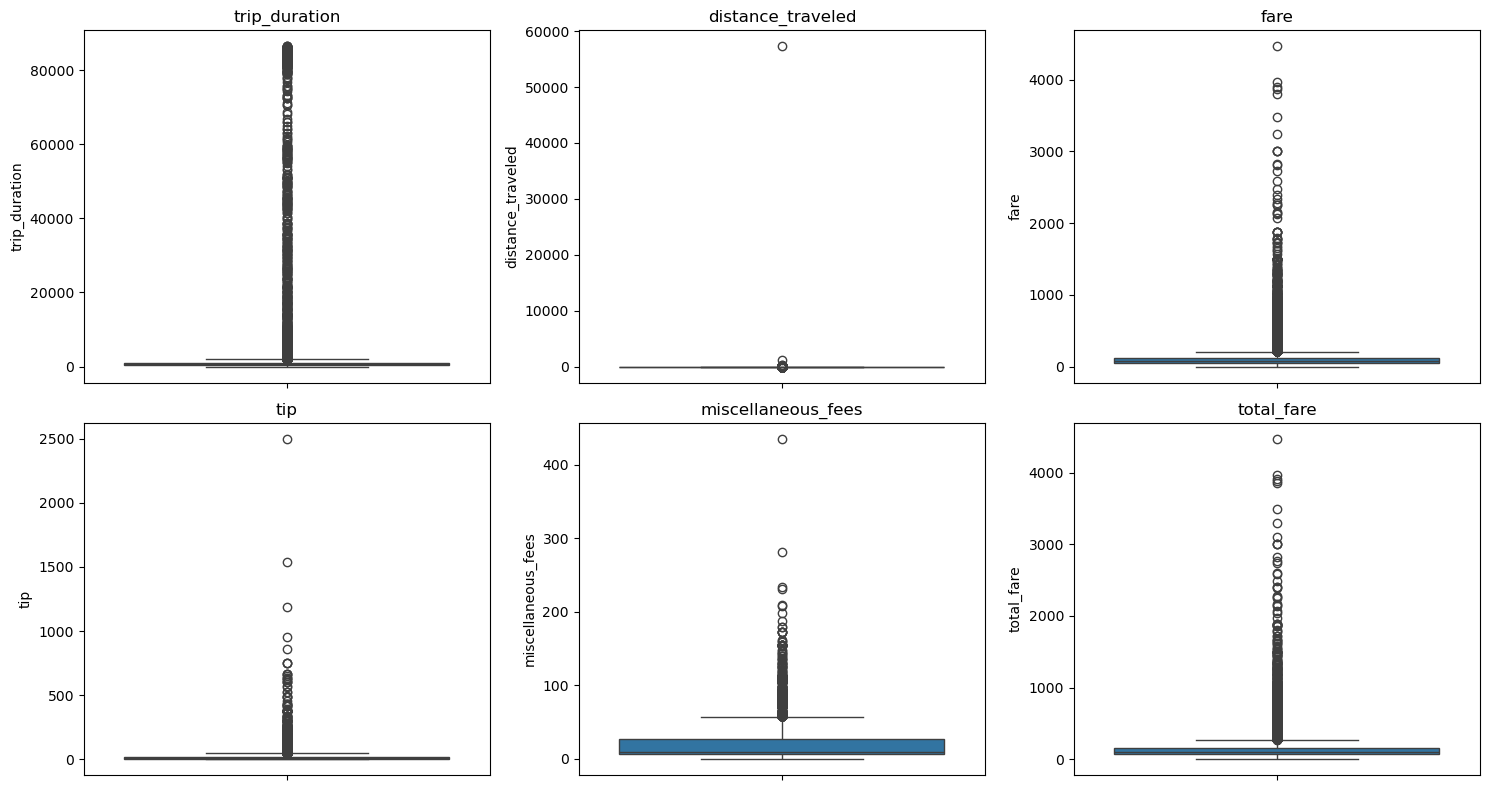

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['trip_duration', 'distance_traveled', 'fare', 'tip', 
            'miscellaneous_fees', 'total_fare']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(num_cols):
    sns.boxplot(y=Taxi_data[col], ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(col)
plt.tight_layout()
plt.show()

<Axes: xlabel='fare', ylabel='Count'>

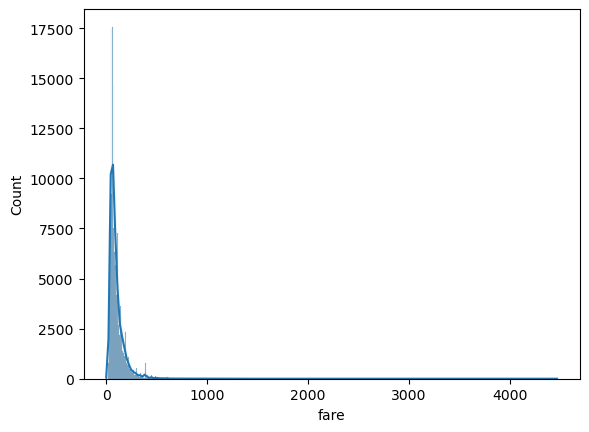

In [13]:
sns.histplot(Taxi_data['fare'], kde=True)

<Axes: xlabel='distance_traveled', ylabel='fare'>

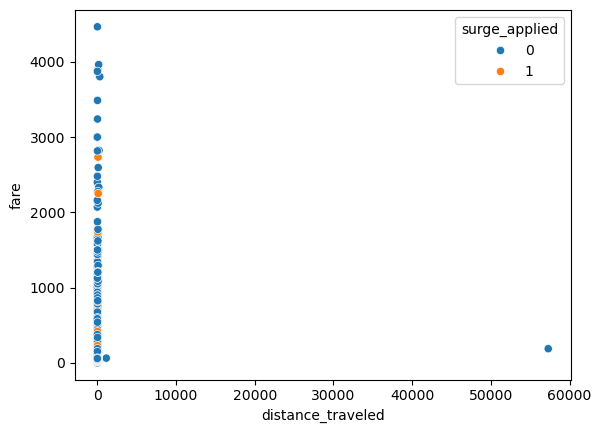

In [14]:
sns.scatterplot(data=Taxi_data, x='distance_traveled', y='fare', hue='surge_applied')

<Axes: >

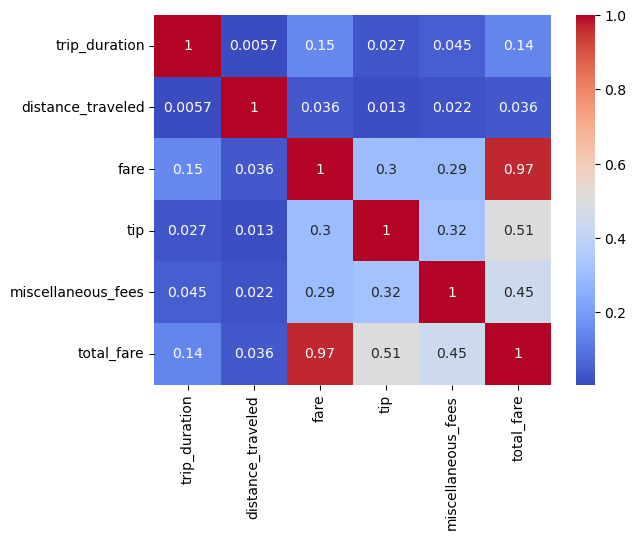

In [15]:
sns.heatmap(Taxi_data[num_cols].corr(), annot=True, cmap='coolwarm')

In [16]:
Taxi_data.columns

Index(['trip_duration', 'distance_traveled', 'num_of_passengers', 'fare',
       'tip', 'miscellaneous_fees', 'total_fare', 'surge_applied'],
      dtype='object')

In [17]:
x = Taxi_data[['trip_duration', 'distance_traveled', 'num_of_passengers', 'tip', 'miscellaneous_fees','surge_applied']]
y = Taxi_data['total_fare']


x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42)
print(f"The train size is {len(x_train)}")
print(f"The test size is {len(x_test)}")


The train size is 164278
The test size is 41070


In [18]:
Numstd=['trip_duration', 'distance_traveled', 'num_of_passengers','tip', 'miscellaneous_fees']

In [19]:
scaler = StandardScaler()
x_train[Numstd] = scaler.fit_transform(x_train[Numstd])
x_test[Numstd] = scaler.transform(x_test[Numstd])


In [20]:
model = LinearRegression()
model.fit(x_train, y_train)
print("Model trained")

Model trained


In [21]:
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
mae=mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
    
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print(f"R2 Score: {r2*100:.2f}%")


MAE: 43.98683424807572
MSE: 5509.1496284519435
RMSE: 74.22364601966103
R2 Score: 39.33%


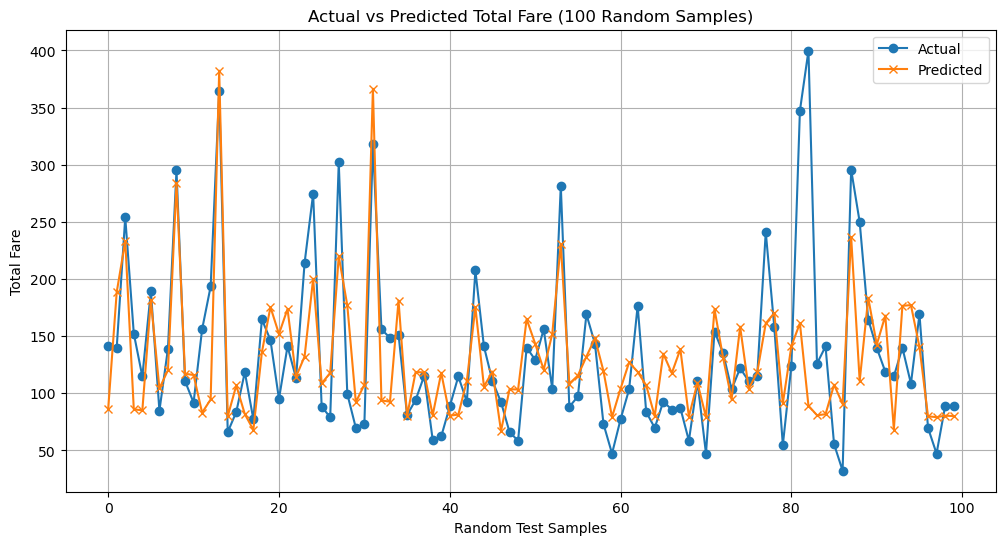

In [25]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

sample = comparison.sample(n=100, random_state=42)

plt.figure(figsize=(12,6))

plt.plot(sample['Actual'].values, label='Actual', marker='o')
plt.plot(sample['Predicted'].values, label='Predicted', marker='x')

plt.xlabel("Random Test Samples")
plt.ylabel("Total Fare")
plt.title("Actual vs Predicted Total Fare (100 Random Samples)")

plt.legend()
plt.grid(True)
plt.show()


In [23]:
import pandas as pd
trip_duration = float(input("Enter trip duration (in seconds): "))
distance_traveled = float(input("Enter distance travelled (in km): "))
num_of_passengers = int(input("Enter number of passengers: "))
tip = float(input("Enter tip amount (in rupees ₹): "))
miscellaneous_fees = float(input("Enter tollgate expense (in rupees ₹): "))
surge_applied = int(input("Is surge applied? (0 = No, 1 = Yes): "))

user_input = pd.DataFrame({
    'trip_duration': [trip_duration],
    'distance_traveled': [distance_traveled],
    'num_of_passengers': [num_of_passengers],
    'tip': [tip],
    'miscellaneous_fees': [miscellaneous_fees],
    'surge_applied': [surge_applied]
})

user_input[Numstd] = scaler.transform(user_input[Numstd])


prediction = model.predict(user_input)

print("\n--- Trip Details ---")
print(f"Trip duration: {trip_duration} seconds")
print(f"Distance travelled: {distance_traveled} km")
print(f"Number of passengers: {num_of_passengers}")
print(f"Tip amount: ₹{tip}")
print(f"Tollgate expense: ₹{miscellaneous_fees}")
print(f"Surge applied: {'Yes' if surge_applied == 1 else 'No'}")

print(f"\nPredicted total fare: ₹{prediction[0]:.2f}")



--- Trip Details ---
Trip duration: 1800.0 seconds
Distance travelled: 35.0 km
Number of passengers: 4
Tip amount: ₹50.0
Tollgate expense: ₹60.0
Surge applied: Yes

Predicted total fare: ₹327.48
